# CIFAR-10 - Convolutional Network (CNN)

## Why CNN for CIFAR-10

Unlike a Fully Connected Network (FCN), a Convolutional Neural Network (CNN) preserves the spatial structure of images. The input is kept in its original shape (`32x32x3`), allowing the model to learn local patterns such as edges, textures, and shapes.

This model uses two convolutional layers with 32 and 64 filters, which progressively learn more complex features. Each convolution is followed by a max pooling layer that reduces spatial dimensions while retaining the most important information. Finally, the feature maps are flattened, and a Dropout layer (`0.5`) is applied to reduce overfitting before the final softmax classification layer.

## Model architecture

- Conv2D (32 filters, `3x3`) + ReLU
- MaxPooling (`2x2`)
- Conv2D (64 filters, `3x3`) + ReLU
- MaxPooling (`2x2`)
- Flatten
- Dropout (`0.5`)
- Dense (10, softmax)

The model contains about **42.4k parameters** (`42,442`), which is significantly fewer than the FCN baseline (**1,738,890**, about 1.7M), while using parameters more efficiently through spatial feature learning.

In [11]:
import os
os.environ["KERAS_BACKEND"] = "tensorflow"

import keras
from keras import layers

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf

In [12]:
# Model / data parameters
num_classes = 10
input_shape = (32, 32, 3)

(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()

# Convert labels from shape (N, 1) to (N,)
y_train = y_train.flatten()
y_test = y_test.flatten()

# Normalize pixel values to [0, 1] - keep images as 32x32x3
x_train = x_train.astype("float32") / 255
x_test = x_test.astype("float32") / 255

print(f"x_train shape: {x_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"x_test shape: {x_test.shape}")
print(f"y_test shape: {y_test.shape}")

x_train shape: (50000, 32, 32, 3)
y_train shape: (50000,)
x_test shape: (10000, 32, 32, 3)
y_test shape: (10000,)


In [13]:
# CNN model for CIFAR-10:
inputs = keras.Input(shape=input_shape)
x = keras.layers.Conv2D(32, kernel_size=(3, 3), activation="relu")(inputs)
x = keras.layers.MaxPooling2D(pool_size=(2, 2))(x)
x = keras.layers.Conv2D(64, kernel_size=(3, 3), activation="relu")(x)
x = keras.layers.MaxPooling2D(pool_size=(2, 2))(x)
x = layers.Flatten()(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(num_classes, activation="softmax")(x)

model = keras.Model(inputs=inputs, outputs=outputs, name="cifar10_cnn")

In [14]:
model.summary()

Model: "cifar10_cnn"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_3 (InputLayer)        [(None, 32, 32, 3)]       0         
                                                                 
 conv2d_4 (Conv2D)           (None, 30, 30, 32)        896       
                                                                 
 max_pooling2d_4 (MaxPoolin  (None, 15, 15, 32)        0         
 g2D)                                                            
                                                                 
 conv2d_5 (Conv2D)           (None, 13, 13, 64)        18496     
                                                                 
 max_pooling2d_5 (MaxPoolin  (None, 6, 6, 64)          0         
 g2D)                                                            
                                                                 
 flatten_2 (Flatten)         (None, 2304)              

In [15]:
model.compile(
    loss=keras.losses.SparseCategoricalCrossentropy(),
    optimizer=keras.optimizers.Adam(),
    metrics=["accuracy"],
)

# Train model
history = model.fit(
    x_train, y_train,   
    batch_size=32,
    epochs=20,
    validation_split=0.2,
)

Epoch 1/20
1250/1250 [==============================] - 4s 3ms/step - loss: 1.5972 - accuracy: 0.4243 - val_loss: 1.3316 - val_accuracy: 0.5343
Epoch 2/20
1250/1250 [==============================] - 3s 3ms/step - loss: 1.2946 - accuracy: 0.5412 - val_loss: 1.1635 - val_accuracy: 0.5972
Epoch 3/20
1250/1250 [==============================] - 4s 3ms/step - loss: 1.1831 - accuracy: 0.5864 - val_loss: 1.1293 - val_accuracy: 0.5986
Epoch 4/20
1250/1250 [==============================] - 4s 3ms/step - loss: 1.1195 - accuracy: 0.6077 - val_loss: 1.0485 - val_accuracy: 0.6334
Epoch 5/20
1250/1250 [==============================] - 3s 3ms/step - loss: 1.0791 - accuracy: 0.6237 - val_loss: 0.9978 - val_accuracy: 0.6553
Epoch 6/20
1250/1250 [==============================] - 5s 4ms/step - loss: 1.0445 - accuracy: 0.6372 - val_loss: 1.0498 - val_accuracy: 0.6404
Epoch 7/20
1250/1250 [==============================] - 5s 4ms/step - loss: 1.0144 - accuracy: 0.6473 - val_loss: 0.9563 - val_accuracy:

## Training results

During training, accuracy improves steadily:

- Training accuracy: **~41.5% -> ~70.4%**
- Validation accuracy: **~53.4% -> ~71.1%**

The loss decreases consistently for both training and validation sets, indicating good convergence. Validation loss does not increase significantly toward the end, suggesting minimal overfitting.

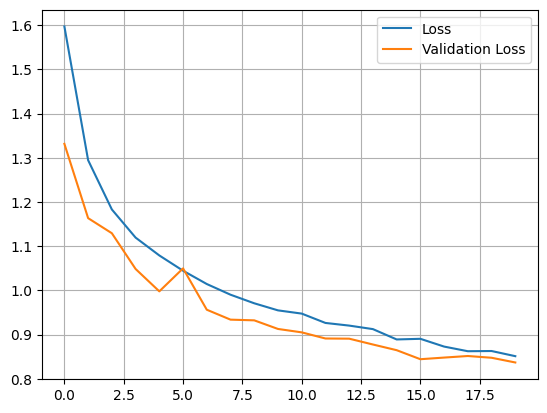

In [16]:
plt.plot(history.history["loss"], label="Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.legend()
plt.grid()
plt.show()

In [17]:
# Evaluate final model on unseen test data
score = model.evaluate(x_test, y_test, verbose=0)
print("Test loss:", score[0])
print("Test accuracy:", score[1])


Test loss: 0.8361294865608215
Test accuracy: 0.7139999866485596


## Test results

- Test accuracy: **~71.16%**
- Test loss: **~0.851**

The test accuracy closely matches the validation accuracy, indicating good generalization to unseen data.

## Results analysis

The CNN clearly outperforms the FCN variants:

| Model | Test accuracy |
|---|---:|
| FCN | ~49.53% |
| FCN + Dropout | ~41.78% |
| CNN | ~71.16% |

This improvement comes from the CNN's ability to:

- preserve spatial structure
- learn local features (edges, shapes)
- use weight sharing, making it more parameter-efficient

The Dropout layer (`0.5`) further helps reduce overfitting, even though the model is already relatively compact.

## Summary

The CNN model achieves significantly better performance on CIFAR-10 compared to the FCN baselines. Despite having fewer parameters, it uses image data much more effectively, highlighting the strength of convolutional neural networks in image classification tasks.

313/313 [==============================] - 0s 1ms/step


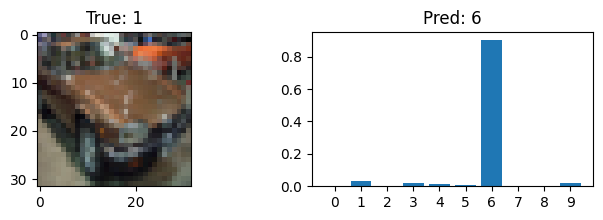

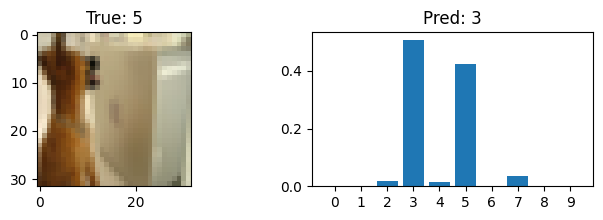

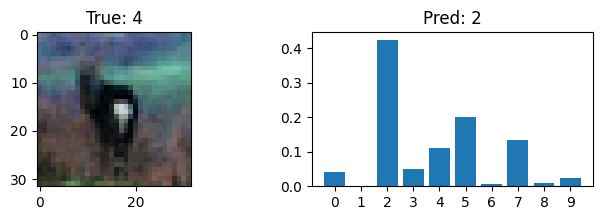

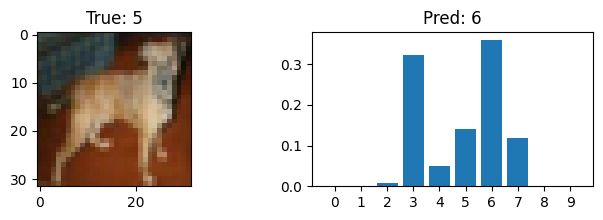

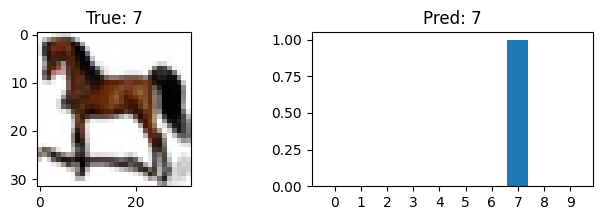

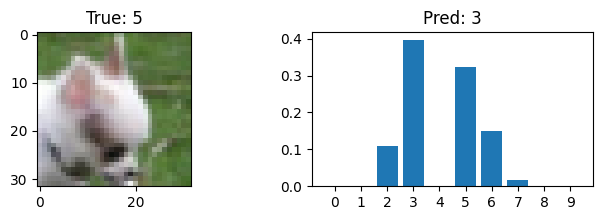

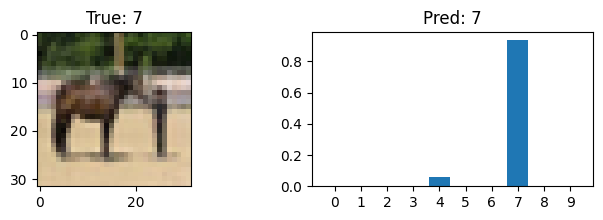

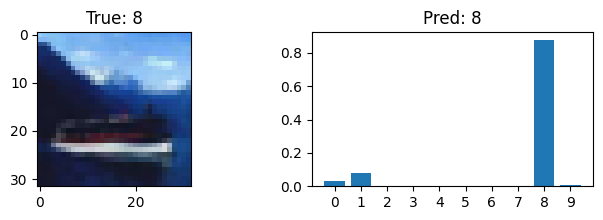

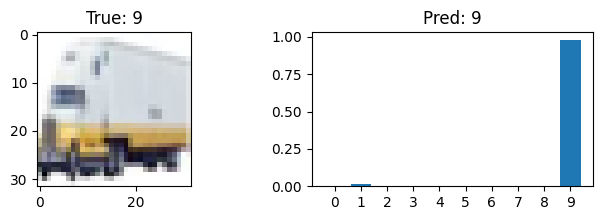

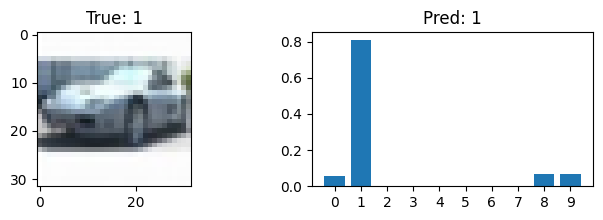

In [18]:
y_pred = model.predict(x_test)
start = 2000

# visualization
for k in range(10):
    plt.figure(figsize=(8, 2))

    plt.subplot(1,2,1)
    plt.imshow(x_test[start+k])
    plt.title(f"True: {y_test[start+k]}")

    plt.subplot(1,2,2)
    plt.bar(range(10), y_pred[start+k].flatten())
    plt.title(f"Pred: {np.argmax(y_pred[start+k])}")

    plt.xticks(range(10))
    plt.show()